In [3]:
print("all ok")

all ok


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
import os 
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [5]:

from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [6]:
response

AIMessage(content='The Great Wall of China isn’t a single, continuous structure built all at once—it’s a network of walls, trenches, and natural barriers that were constructed, rebuilt, and expanded over many dynasties.  \n\n**Total measured length (including all known sections):**  \n\n- **≈\u202f21,196\u202fkilometers** (about **13,171\u202fmiles**)  \n\nThis figure comes from the most recent comprehensive survey carried out by China’s State Administration of Cultural Heritage in 2012, which added many previously undocumented sections (including earthen walls, mountain passes, and river‑crossing fortifications) to the total.\n\n### Why the number varies\n- **Historical phases:** Different dynasties (e.g., Qin, Han, Sui, Ming) built separate stretches. The famous “Ming Great Wall” alone is roughly 8,850\u202fkm (5,500\u202fmi).\n- **Definitions:** Some counts include only stone/brick walls, while others also count earthen ramparts, natural barriers, and auxiliary structures.\n- **Ongo

In [7]:
response.content

'The Great Wall of China isn’t a single, continuous structure built all at once—it’s a network of walls, trenches, and natural barriers that were constructed, rebuilt, and expanded over many dynasties.  \n\n**Total measured length (including all known sections):**  \n\n- **≈\u202f21,196\u202fkilometers** (about **13,171\u202fmiles**)  \n\nThis figure comes from the most recent comprehensive survey carried out by China’s State Administration of Cultural Heritage in 2012, which added many previously undocumented sections (including earthen walls, mountain passes, and river‑crossing fortifications) to the total.\n\n### Why the number varies\n- **Historical phases:** Different dynasties (e.g., Qin, Han, Sui, Ming) built separate stretches. The famous “Ming Great Wall” alone is roughly 8,850\u202fkm (5,500\u202fmi).\n- **Definitions:** Some counts include only stone/brick walls, while others also count earthen ramparts, natural barriers, and auxiliary structures.\n- **Ongoing discoveries:**

In [8]:
from langchain.tools import tool

## this is my custom tools

In [9]:
from langchain.tools import tool

@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers, converting the first number to an integer before multiplication.

    Args:
        a (float): The first number. This will be converted to an integer before multiplication.
        b (float): The second number.

    Returns:
        float: The product of the integer part of 'a' and 'b'.
    """
    return int(a) * b

@tool
def add(a: float, b: float) -> float:
    """
    Add two numbers.

    Args:
        a (float): The first number.
        b (float): The second number.

    Returns:
        float: The sum of a and b.
    """
    return a + b

@tool
def divide(a: float, b: float) -> float:
    """
    Divide two numbers.

    Args:
        a (float): The numerator.
        b (float): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

## importing the inbuilt tool

In [10]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [11]:
search.invoke("what is the latest update on iphone17 release?")

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


'No good DuckDuckGo Search Result was found'

In [12]:
# !pip install duckduckgo_search


In [13]:
tools=[multiply, add, divide, search]

In [14]:
llm_with_tools=llm.bind_tools(tools)

In [15]:
response=llm_with_tools.invoke("hi")

In [16]:
response.content

'Hello! How can I help you today?'

In [17]:
response.tool_calls

[]

In [18]:
response=llm_with_tools.invoke("what is 2+2?")

In [19]:
response.content

'2\u202f+\u202f2\u202f=\u202f4.'

In [20]:
response.tool_calls

[]

In [21]:
response=llm_with_tools.invoke("what is 10/2?")

In [22]:
response.content

''

In [23]:
response.tool_calls

[{'name': 'divide',
  'args': {'a': 10, 'b': 2},
  'id': 'fc_6ffdec42-ab05-4219-9540-b20be2804e54',
  'type': 'tool_call'}]

In [24]:
response=llm_with_tools.invoke("what is a current age of the TATA Group?")

In [25]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is a current age of the TATA Group?" They want the age (how many years since founding). Need current age as of now (2025). Need to know founding year of Tata Group. Tata Group was founded in 1868 by Jamsetji Tata. So age = 2025 - 1868 = 157 years. However need to verify if it\'s 1868 or 1868? Actually Tata Group\'s origin: The company was founded in 1868 as a trading firm. So age = 2025 - 1868 = 157. If current date is Dec 27 2025, then age is 157 years (or 157 years and some months). Provide answer. Might need to confirm via search. Use duckduckgo search to verify founding year.', 'tool_calls': [{'id': 'fc_55ce3f4e-cfc5-4860-b482-dca1162b9816', 'function': {'arguments': '{"query":"Tata Group founded year"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 203, 'prompt_tokens': 363, 'total_tokens': 566, 'completion_time': 0.43475857, 'prompt_t

In [26]:
response.content

''

In [27]:
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'Tata Group founded year'},
  'id': 'fc_55ce3f4e-cfc5-4860-b482-dca1162b9816',
  'type': 'tool_call'}]

In [28]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [29]:
SYSTEM_PROMPT="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs."



In [30]:
user_query=["tell me what is 2+2"]

In [31]:
[SYSTEM_PROMPT]+user_query

['You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.',
 'tell me what is 2+2']

In [69]:
def function_1(state:MessagesState):

    user_question=state["messages"]

    input_question = [SYSTEM_PROMPT]+user_question

    response = llm_with_tools.invoke(input_question)

    return {
        "messages":[response]
    }



In [34]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [35]:
builder=StateGraph(MessagesState)

In [70]:
builder.add_node("llm_decision_step",function_1)

In [37]:
tools

[StructuredTool(name='multiply', description="Multiply two numbers, converting the first number to an integer before multiplication.\n\nArgs:\n    a (float): The first number. This will be converted to an integer before multiplication.\n    b (float): The second number.\n\nReturns:\n    float: The product of the integer part of 'a' and 'b'.", args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x10dc66de0>),
 StructuredTool(name='add', description='Add two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x10dc66d40>),
 StructuredTool(name='divide', description='Divide two numbers.\n\nArgs:\n    a (float): The numerator.\n    b (float): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<functi

In [38]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [39]:
builder.add_edge(START,"llm_decision_step")

In [40]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)


In [41]:
builder.add_edge("tools","llm_decision_step")

In [71]:
react_graph=builder.compile()

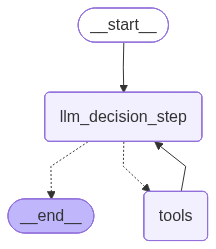

In [72]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [44]:
message=[HumanMessage(content="What is 2 times of narendramodi's age?")]

In [73]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='What is the speed of light in m/s and multiply it by 10?', additional_kwargs={}, response_metadata={}, id='d5587640-cc2b-4e88-934b-25a1cb7c15ff'),
  AIMessage(content='The speed of light in a vacuum is **299,792,458\u202fm/s**.  \n\nMultiplying that by 10:\n\n\\[\n299,792,458 \\times 10 = 2,997,924,580\n\\]\n\nSo the result is **2,997,924,580\u202fm/s**.', additional_kwargs={'reasoning_content': 'We need to answer: speed of light in m/s and multiply by 10. Speed of light is 299,792,458 m/s. Multiply by 10 = 2,997,924,580. Provide answer. No need for tools.'}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 475, 'total_tokens': 604, 'completion_time': 0.271656262, 'prompt_time': 0.020328442, 'queue_time': 0.049370986, 'total_time': 0.291984704, 'completion_tokens_details': {'reasoning_tokens': 53}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 's

In [46]:
message = [HumanMessage(content="How much is the net worth of Elon Musk, and divide it by 2?")]

In [74]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='What is the speed of light in m/s and multiply it by 10?', additional_kwargs={}, response_metadata={}, id='d5587640-cc2b-4e88-934b-25a1cb7c15ff'),
  AIMessage(content='The speed of light in a vacuum is **299,792,458\u202fm/s**.  \n\nMultiplying that by 10:\n\n\\[\n299,792,458 \\times 10 = 2,997,924,580\n\\]\n\nSo, ten times the speed of light is **2,997,924,580\u202fm/s**.', additional_kwargs={'reasoning_content': 'We need to answer: speed of light in m/s and multiply by 10. Speed of light is 299,792,458 m/s. Multiply by 10 = 2,997,924,580. Provide answer. No need for tools.'}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 475, 'total_tokens': 609, 'completion_time': 0.277194432, 'prompt_time': 0.018917441, 'queue_time': 0.054248839, 'total_time': 0.296111873, 'completion_tokens_details': {'reasoning_tokens': 53}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 

In [48]:
message = [HumanMessage(content="What is the speed of light in m/s and multiply it by 10?")]

In [75]:
response=react_graph.invoke({"messages":message})

In [76]:
response["messages"][-1].content

'The speed of light in a vacuum is **299,792,458\u202fm/s**.  \n\nMultiplying that by 10 gives **2,997,924,580\u202fm/s**.'

In [77]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the speed of light in m/s and multiply it by 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_3cddbb38-d1c9-4545-b51b-06819ce20999)
 Call ID: fc_3cddbb38-d1c9-4545-b51b-06819ce20999
  Args:
    a: 299792458
    b: 10
================================= Tool Message =================================
Name: multiply

2997924580.0
================================== Ai Message ==================================

The speed of light in a vacuum is **299,792,458 m/s**.  

Multiplying that by 10 gives **2,997,924,580 m/s**.


In [52]:
import yfinance as yf

In [53]:
@tool
def get_stock_price(ticker:str)->str:
    """
    Fetches the previous closing price of a given stock ticker from Yahoo Finance.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'AAPL', 'TSLA', 'NIFTY.BO').

    Returns:
        str: A message with the stock's previous closing price.
    """
    try:
        stock = yf.Ticker(ticker)
        price = stock.info.get('previousClose')
        if price is None:
            return f"Could not fetch price for ticker '{ticker}'."
        return f"The last closing price of {ticker.upper()} was ${price:.2f}."
    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"



In [54]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $273.81.'

In [55]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $485.40.'

In [56]:
tools

[StructuredTool(name='multiply', description="Multiply two numbers, converting the first number to an integer before multiplication.\n\nArgs:\n    a (float): The first number. This will be converted to an integer before multiplication.\n    b (float): The second number.\n\nReturns:\n    float: The product of the integer part of 'a' and 'b'.", args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x10dc66de0>),
 StructuredTool(name='add', description='Add two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The sum of a and b.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x10dc66d40>),
 StructuredTool(name='divide', description='Divide two numbers.\n\nArgs:\n    a (float): The numerator.\n    b (float): The denominator (must not be 0).\n\nReturns:\n    float: The result of division.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<functi

In [57]:
tools = [add, multiply, divide, search,get_stock_price]

In [58]:
llm_with_tools=llm.bind_tools(tools)

In [59]:
response=llm_with_tools.invoke("can you give me a latest stock price of adani greens?")

In [60]:
response.content

''

In [61]:
response.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'ADANIGREEN.NS'},
  'id': 'fc_bd82aeba-f398-4719-9388-2361f18418c0',
  'type': 'tool_call'}]

In [62]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using search, the yahoo finance tool and performing arithmetic on a set of inputs."
)
def function_1(state:MessagesState):

    user_question=state["messages"]

    input_question = [SYSTEM_PROMPT]+user_question

    response = llm_with_tools.invoke(input_question)

    return {
        "messages":[response]
    }

In [63]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

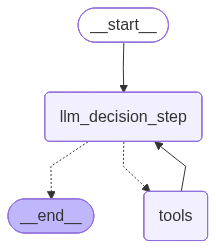

In [64]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [65]:
messages = [HumanMessage(content="add 1000 in the current stock price of Apple.")]
messages = react_graph2.invoke({"messages": messages})

In [66]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 1000 in the current stock price of Apple.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (fc_ae8bb9fd-100f-408d-ba68-eaac1e978830)
 Call ID: fc_ae8bb9fd-100f-408d-ba68-eaac1e978830
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

The last closing price of AAPL was $273.81.
================================== Ai Message ==================================
Tool Calls:
  add (fc_bee482a8-6c3f-4aab-a4fe-7f3c703ce1b8)
 Call ID: fc_bee482a8-6c3f-4aab-a4fe-7f3c703ce1b8
  Args:
    a: 273.81
    b: 1000
================================= Tool Message =================================
Name: add

1273.81
================================== Ai Message ==================================

The result of adding $1000 to Apple’s last closing price ($273.81) is **$1,273.81**.


In [67]:
messages = [HumanMessage(content="can you give me the iphone 17 pro max price.")]
messages = react_graph2.invoke({"messages": messages})

/Users/saicharan/Artificial Intellegence/artificialintellegence/lib/python3.12/site-packages/langchain_community/utilities/duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


In [68]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

can you give me the iphone 17 pro max price.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fc_811ce398-dca1-4ca0-92f8-eb8f9da73a53)
 Call ID: fc_811ce398-dca1-4ca0-92f8-eb8f9da73a53
  Args:
    query: iPhone 17 Pro Max price
================================= Tool Message =================================
Name: duckduckgo_search

Get ₹3350.00–₹64000.00 off a new iPhone 17 or iPhone 17 Plus when you trade in an iPhone 7 Plus or newer. Buy now with free shipping. Buy Apple iPhone 17 Pro Max online at best price with offers in India. Apple iPhone 17 Pro Max (Cosmic Orange, 256 GB) features and specifications include 256 GB ROM, 48 MP back camera and 18 MP … LIGHTNING FAST — A19 Pro is the most powerful iPhone chip yet, delivering up to 40% better sustained performance. BEST BATTERY LIFE IN ANY IPHONE — The unibody design creates … Dec 16, 202

In [ ]:
#next class:
1. #human in loop
2.## agentic RAG
3.# multiagent system(collabation and supervisor)
4.# some mislionoius concept of the langgraph: sub graph, parllal execution etc

In [ ]:
  Assignment:

  AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")

  • Real-time weather information
  • Top attractions and activities
  • Hotel cost calculation (per day × total days)
  • Currency conversion to user's native currency
  • Complete itinerary generation
  • Total expense calculation
  • generate a summary of the entire output

  user_input
    |
  search attraction and activity
  1. search attracation
  2. search restaurant
  3. search activity
  4. search transportation
    |
  search weather forcasting
  1. get current weather
  2. get weather forcast
    |
  search hotel costs
  1. search hotel
  2. estimate the hotel cost
  3. budget_range
    |
  calculate total cost
  1. add
  2. multiply
  3. calculated total cost
  4. calcualte the daily budget
      |
  currency_converion
  1. get exchnage rate
  2. convert currancy
      |
  Itinery generation
  1. get day plan
  2. crete full itinery
      |
  create Trip Summary
      |
  Retun complete traval plan

  Note: if you know the OOPS then design this entire system using object and class in modular fashion.


  deadline is till next friday 9PM IST


  everyone you can submit the assignments in this form. MAke sure to have one GitHub link and put all the assignments there https://forms.gle/g8RZ4qx8yvNcih4B7  ###
